In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from datetime import datetime

tickers = ['NVDA']
data = yf.download(tickers, start="2015-07-21", end=datetime.now(), auto_adjust=False)
# Check the data
print(tabulate(data.tail(10), headers='keys', tablefmt='psql'))


[*********************100%***********************]  1 of 1 completed

+---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------+
| Date                |   ('Adj Close', 'NVDA') |   ('Close', 'NVDA') |   ('High', 'NVDA') |   ('Low', 'NVDA') |   ('Open', 'NVDA') |   ('Volume', 'NVDA') |
|---------------------+-------------------------+---------------------+--------------------+-------------------+--------------------+----------------------|
| 2025-07-31 00:00:00 |                  177.87 |              177.87 |            183.3   |            175.93 |            182.9   |          2.21685e+08 |
| 2025-08-01 00:00:00 |                  173.72 |              173.72 |            176.54  |            170.89 |            174.09  |          2.04529e+08 |
| 2025-08-04 00:00:00 |                  180    |              180    |            180.2   |            174.52 |            175.16  |          1.48175e+08 |
| 2025-08-05 00:00:00 |                  178.26 |         

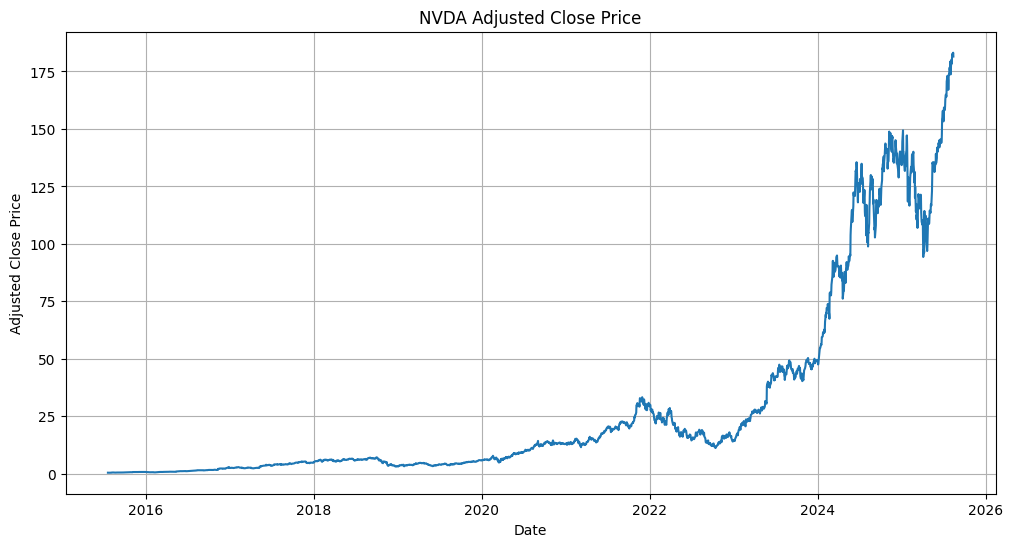

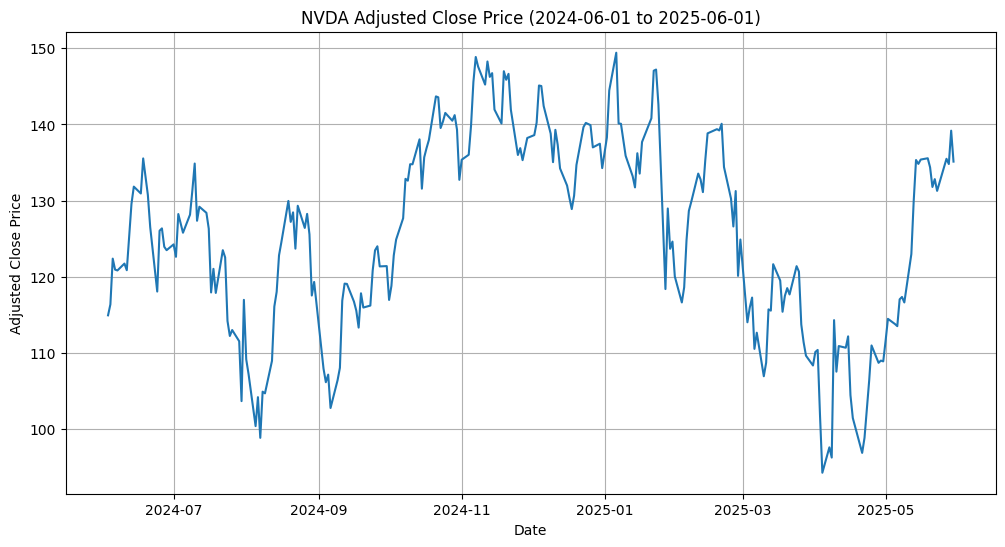

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data[('Adj Close', 'NVDA')])
plt.title('NVDA Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()

# Filter the date range
filtered_data = data.loc['2024-06-01':'2025-06-01']

# Plot
plt.figure(figsize=(12, 6))
plt.plot(filtered_data.index, filtered_data[('Adj Close', 'NVDA')])
plt.title('NVDA Adjusted Close Price (2024-06-01 to 2025-06-01)')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()

In [36]:
import requests
from datetime import datetime

api_key = 'd2ea8opr01qr1ro8v0v0d2ea8opr01qr1ro8v0vg'
symbol = 'NVDA'

# Fetch news
r = requests.get(
    f"https://finnhub.io/api/v1/company-news?symbol={symbol}&from=2024-09-01&to=2024-10-01&token={api_key}"
)
news = r.json()

# Add readable_date field
for article in news:
    article['readable_date'] = datetime.fromtimestamp(article['datetime']).strftime('%Y-%m-%d %H:%M:%S')

print("Length", len(news));
news

Length 214


[{'category': 'company',
  'datetime': 1727818641,
  'headline': 'How to play tech amid recent volatility',
  'id': 130174002,
  'image': 'https://s.yimg.com/ny/api/res/1.2/8fMyoCkaENmJvEFQmmrgZA--/YXBwaWQ9aGlnaGxhbmRlcjt3PTEyMDA7aD02NzY-/https://s.yimg.com/os/creatr-uploaded-images/2024-10/4a695ea0-803b-11ef-bcdf-5adc502a9410',
  'related': 'NVDA',
  'source': 'Yahoo',
  'summary': 'As the Nasdaq (^IXIC) is down the most out of the three major indexes (^DJI,^GSPC), investors may be wondering if now is the time to buy on the dip. Jason Browne, Alexis Investment Partners president, joins Julie Hyman and Josh Lipton on Market Domination to discuss how recent volatility could be an opportunity to buy into tech. “We have a lot of negative news hitting simultaneous[ly] to the pullback. If we can look at those as opportunities to add to things that we may have missed out on or maybe underweight in that tends to work out well over time. The other thing to note is with tech, particularly [when

In [38]:
print(f"First: {news[-1]}")
print(f"Last: {news[0]}")

Last: {'category': 'company', 'datetime': 1727818641, 'headline': 'How to play tech amid recent volatility', 'id': 130174002, 'image': 'https://s.yimg.com/ny/api/res/1.2/8fMyoCkaENmJvEFQmmrgZA--/YXBwaWQ9aGlnaGxhbmRlcjt3PTEyMDA7aD02NzY-/https://s.yimg.com/os/creatr-uploaded-images/2024-10/4a695ea0-803b-11ef-bcdf-5adc502a9410', 'related': 'NVDA', 'source': 'Yahoo', 'summary': 'As the Nasdaq (^IXIC) is down the most out of the three major indexes (^DJI,^GSPC), investors may be wondering if now is the time to buy on the dip. Jason Browne, Alexis Investment Partners president, joins Julie Hyman and Josh Lipton on Market Domination to discuss how recent volatility could be an opportunity to buy into tech. “We have a lot of negative news hitting simultaneous[ly] to the pullback. If we can look at those as opportunities to add to things that we may have missed out on or maybe underweight in that tends to work out well over time. The other thing to note is with tech, particularly [when] we\'re 

In [39]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.6 MB/s eta 0:00:00


In [41]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
for article in news:
    sentiment = analyzer.polarity_scores(article['headline'])
    print(article['datetime'], article['headline'], sentiment['compound'])

1727818641 How to play tech amid recent volatility 0.34
1727801460 Nvidia Stock Slips to Start a Crucial Quarter. What’s at Stake. 0.0
1727813201 Tesla's China Rivals Set Delivery Records; Archrival BYD Tops 1 Million EV Milestone 0.5106
1727810015 Cerebras hopes planned IPO will supercharge its race against Nvidia and fellow chip startups for the fastest generative AI 0.4215
1727809427 Why Nvidia, Micron, Broadcom, and Other Artificial Intelligence (AI) and Semiconductor Stocks Slumped on Tuesday 0.4767
1727807820 AI Demand Will Lift These 3 Infrastructure Stocks, Says J.P. Morgan. -0.128
1727807700 Nvidia rival Cerebras Systems files for IPO as demand for chips soars and investors hunger for AI stocks -0.3612
1727807109 IGV: Not A Bargain P/E, But One Technical Pattern Catches My Attention (Rating Upgrade) -0.0762
1727804189 A New AI Chip Stock? Startup Challenging Nvidia Files For IPO 0.1531
1727802000 S&P 500's Best Nine-Month Since 1997: Winning ETFs & Stocks 0.8225
1727801136 Nvi